In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
from torch.optim import AdamW  # En lugar de transformers
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

In [ ]:
# Cargar datasets
df_train_sa = pd.read_csv('dfSentimentAnalysis_ft_train.csv')
df_test_sa = pd.read_csv('dfSentimentAnalysis_ft_test.csv')
df_train_hs = pd.read_csv('dfHateSpeech_ft_train.csv')
df_test_hs = pd.read_csv('dfHateSpeech_ft_test.csv')

In [ ]:
# Tokenizers
tokenizer_sa = AutoTokenizer.from_pretrained("pysentimiento/robertuito-sentiment-analysis")
tokenizer_hs = AutoTokenizer.from_pretrained("pysentimiento/robertuito-hate-speech")

La función tokenizar toma como entrada un diccionario (o un lote de estos, si batched=True), con la clave "text" y le aplica el tokenizer de pysentimiento.

Parámetros:
* padding="max_length": completa todos los textos hasta max_length con tokens especiales.
* truncation=True: corta los textos que superen max_length.
* max_length=128: define el largo máximo de tokens.

El resultado es un Dataset igual al original, pero con nuevas columnas agregadas:

* input_ids: contiene los IDs numéricos de los tokens que corresponden al texto de entrada.
* attention_mask: máscara binaria (0 y 1) que in

In [ ]:
# Tokenización
def tokenize(batch, tokenizer):
    textos = [str(t) for t in batch["text"]]
    return tokenizer(
        textos,
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Convertir a Dataset de Hugging Face
train_sa_dataset = Dataset.from_pandas(df_train_sa).map(lambda batch: tokenize(batch, tokenizer_sa), batched=True)
test_sa_dataset = Dataset.from_pandas(df_test_sa).map(lambda batch: tokenize(batch, tokenizer_sa), batched=True)
train_hs_dataset = Dataset.from_pandas(df_train_hs).map(lambda batch: tokenize(batch, tokenizer_hs), batched=True)
test_hs_dataset = Dataset.from_pandas(df_test_hs).map(lambda batch: tokenize(batch, tokenizer_hs), batched=True)

Map:   0%|          | 0/54000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/54000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

In [ ]:
# Definimos métricas que utilizaremos para evaluar los modelos tuneados
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'precision_macro': precision_score(labels, preds, average='macro'),
        'recall_macro': recall_score(labels, preds, average='macro')
    }

In [ ]:
# Custom callback para loguear métricas durante el entrenamiento con Hugging Face Trainer
class CustomLoggingCallback(TrainerCallback):
    def __init__(self, log_dir, backup_dir):
        # Definimos los directorios donde se van a guardar los logs y los backups
        self.log_dir = log_dir
        self.backup_dir = backup_dir
        # Si no existen los creamos
        os.makedirs(log_dir, exist_ok=True)
        os.makedirs(backup_dir, exist_ok=True)

        # Definimos las rutas donde se van a guardar los CSV de logs de pérdidas y métricas
        self.loss_log_path = os.path.join(log_dir, "loss_log.csv")
        self.metric_log_path = os.path.join(log_dir, "metrics_log.csv")
        # Si no existen los creamos con sus respectivas columnas
        if not os.path.exists(self.loss_log_path):
            pd.DataFrame(columns=["step", "loss"]).to_csv(self.loss_log_path, index=False)
        if not os.path.exists(self.metric_log_path):
            pd.DataFrame(columns=["step", "metric_name", "value"]).to_csv(self.metric_log_path, index=False)

    # Este método se ejecuta cada vez que el Trainer genera logs
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return  # Si no hay logs, salimos

        # Obtenemos el número de step global (número total de iteraciones hasta ese momento)
        step = state.global_step

        # Guardamos cada 50 batches procesados la loss en ese punto que tiene el modelo durante el entrenamiento
        if "loss" in logs and step % 50 == 0:
            # Leemos el log anterior
            df = pd.read_csv(self.loss_log_path)
            # Agregamos la pérdida actual
            df = pd.concat([df, pd.DataFrame([{"step": step, "loss": logs["loss"]}])], ignore_index=True)
            # Guardamos el archivo actualizado
            df.to_csv(self.loss_log_path, index=False)

        # Cada 1000 steps, realizamos un backup automático de los logs
        if step % 1000 == 0 and step != 0:
            print(f"Backup automático en step {step}")
            # Copiamos la carpeta de logs al directorio de backups
            os.system(f"cp -r {self.log_dir} {self.backup_dir}")

        # Recorremos todas las métricas logueadas en ese step
        for key in logs:
            # Si es una métrica de evaluación
            if key.startswith("eval_"):
                # Leemos el log anterior de métricas
                df_metrics = pd.read_csv(self.metric_log_path)
                # Agregamos la métrica actual
                df_metrics = pd.concat([df_metrics, pd.DataFrame([{
                    "step": step, "metric_name": key, "value": logs[key]
                }])], ignore_index=True)
                # Guardamos el archivo actualizado
                df_metrics.to_csv(self.metric_log_path, index=False)

In [ ]:
# Obtenemos el último checkpoint en caso de existir este
def get_last_checkpoint(output_dir):
    checkpoints = [os.path.join(output_dir, d) for d in os.listdir(output_dir) if d.startswith("checkpoint")]
    return max(checkpoints, key=os.path.getmtime) if checkpoints else None

Realizamos el entrenamiento del modelo a partir de fine tunear el equivalente de pysentimiento.

Parametros:
* train_dataset: dataset de entrenamiento

* test_dataset: dataset de evaluación

* model_checkpoint: nombre o path del modelo preentrenado

* num_labels: cantidad de clases de salida

* output_dir: carpeta donde se guardarán los outputs

* total_epochs: cantidad de épocas de entrenamiento (por defecto 3)

In [ ]:
# Entrenamiento
def train_model(train_dataset, test_dataset, model_checkpoint, num_labels, output_dir, total_epochs=3):

    # Creamos el directorio de salida si este no existe
    os.makedirs(output_dir, exist_ok=True)
    checkpoint_path = get_last_checkpoint(output_dir)

    # Buscamos si existe un checkpoint previo en la carpeta de salida
    if checkpoint_path:
        print(f"Reanudando desde checkpoint: {checkpoint_path}")
        model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path, num_labels=num_labels)
    else:
        # Si no hay checkpoint, cargamos el modelo base desde Hugging Face
        print(f"No se encontró checkpoint previo. Arrancando desde: {model_checkpoint}")
        model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels,ignore_mismatched_sizes=True)
        model.config.problem_type = "single_label_classification" # Para HateSpeech

        # Congelamos todos los parámetros del modelo base para no actualizarlos en el entrenamiento
        for param in model.base_model.parameters():
            param.requires_grad = False

        # Descongelamos solo las dos últimas capas del encoder para hacer fine-tuning
        for layer in model.base_model.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Descongelamos la capa de clasificación final
        for param in model.classifier.parameters():
            param.requires_grad = True

    # Definimos los argumentos de entrenamiento
    training_args = TrainingArguments(
        output_dir=output_dir,                  # A donde redireccionamos la salida de logs y checkpoints
        num_train_epochs=total_epochs,          # Cantidad de épocas del entrenamiento
        per_device_train_batch_size=16,         # Batch size para entrenamiento
        per_device_eval_batch_size=16,          # Batch size para evaluación
        save_strategy="steps",                  # Cada cierta cantidad de steps guardamos el entrenamiento en ese punto
        save_steps=100,                         # Cada 100 steps guardamos un checkpoint
        logging_steps=50,                       # Cada 50 steps hacemos log de métricas y lo guardaremos
        weight_decay=0.01,                      # Parámetro de regularización L2
        learning_rate=1e-4,                     # Learning rate inicial
        warmup_steps=500,                       # Cantidad de warmup steps (para learning rate lineal)
        lr_scheduler_type="linear",             # Planificador de learning rate lineal
        metric_for_best_model="f1_macro",       # Métrica que tendrá en cuenta para determinar el mejor modelo
        logging_dir=f"{output_dir}/logs",       # Carpeta para guardar logs de TensorBoard
        save_total_limit=2,                     # Máxima cantidad de checkpoints que conservará
        load_best_model_at_end=False,           # No cargaremos el mejor modelo al final
        eval_steps=100                          # Cada 100 steps realizamos una evaluación
    )

    # Utilizaremos el optimizador AdamW con weight decay
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    # Creamos una instancia de Trainer con el modelo, los argumentos y datasets
    trainer = Trainer(
        model=model,                       # Modelo a entrenar
        args=training_args,                # Argumentos de entrenamiento
        train_dataset=train_dataset,       # Dataset de entrenamiento
        eval_dataset=test_dataset,         # Dataset de evaluación
        compute_metrics=compute_metrics,   # Función para calcular métricas personalizadas
        optimizers=(optimizer, None),      # Optimizador (sin scheduler)
        callbacks=[CustomLoggingCallback(log_dir=output_dir, backup_dir=f"{output_dir}_backup")] # Callback custom para logs y backups
    )

    # Iniciamos el entrenamiento, reanudando desde el último checkpoint, si corresponde
    trainer.train(resume_from_checkpoint=checkpoint_path)
    # Evaluamos el modelo sobre el dataset de evaluacion al finalizar el entrenamiento
    results = trainer.evaluate()
    # Obtienemos la pérdida de evaluación
    eval_loss = results.get('eval_loss', float('inf'))
    print(f"Pérdida de evaluación: {eval_loss}")

    # Obtenemos las predicciones sobre el dataset de evaluacion
    predictions = trainer.predict(test_dataset)
    # Extraemos los labels con las clasificaciones reales
    labels = predictions.label_ids
    # Obtenemos la clase predicha con mayor probabilidad para cada muestra
    preds = np.argmax(predictions.predictions, axis=1)
    # Calculamos las métricas finales sobre las predicciones
    metrics = compute_metrics(predictions)

    return trainer, metrics, labels, preds, test_dataset

In [ ]:
# Ejecutar fine tuning
trainer_sa, metrics_sa, labels_sa, preds_sa, test_sa = train_model(
    train_dataset=train_sa_dataset,     # Dataset de entrenamiento
    test_dataset=test_sa_dataset,       # Dataset de evaluación
    model_checkpoint="pysentimiento/robertuito-sentiment-analysis", # Modelo de hugging face sobre el cual haremos el tuneo
    num_labels=3,                       # 3 categorías posibles de sentimientos tenemos para cada tweet
    output_dir="Checkpoints_Sentiment", # Carpeta de salida sobre la que se irán guardando las métricas y los checkpoints de los backups
    total_epochs=4                      # 4 épocas para el dataset de análisis de sentimiento
)

Reanudando desde checkpoint: Checkpoints_Sentiment/checkpoint-13500


Step,Training Loss


/home/USURIO/pln_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Pérdida de evaluación: 1.1980046033859253


/home/USURIO/pln_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
print("Sentiment Analysis")
print(classification_report(labels_sa, preds_sa, digits=4))
print(confusion_matrix(labels_sa, preds_sa))

Sentiment Analysis
              precision    recall  f1-score   support

           0     0.6646    0.7065    0.6849      2000
           1     0.6277    0.6060    0.6166      2000
           2     0.6927    0.6730    0.6827      2000

    accuracy                         0.6618      6000
   macro avg     0.6617    0.6618    0.6614      6000
weighted avg     0.6617    0.6618    0.6614      6000

[[1413  340  247]
 [ 438 1212  350]
 [ 275  379 1346]]


In [ ]:
# Graficas Sentiment Analysis Tuneo

In [ ]:
# Hate Speech
trainer_hs, metrics_hs, labels_hs, preds_hs, test_hs = train_model(
    train_dataset=train_hs_dataset, # Dataset de entrenamiento
    test_dataset=test_hs_dataset,   # Dataset de evaluación
    model_checkpoint="pysentimiento/robertuito-hate-speech",  # Modelo de hugging face sobre el cual haremos el tuneo
    num_labels=2,                    # 2 categorías posibles de discurso de odio tenemos para cada tweet
    output_dir="Checkpoints_Hate",   # Carpeta de salida sobre la que se irán guardando las métricas y los checkpoints de los backups
    total_epochs=2                   # 2 épocas para el dataset de discurso de odio
)

Reanudando desde checkpoint: Checkpoints_Hate/checkpoint-6600


/home/USURIO/pln_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
6650,0.350600
6700,0.345200
6750,0.345800


/home/USURIO/pln_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/tmp/ipykernel_302699/1980747986.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([df_metrics, pd.DataFrame([{
/home/USURIO/pln_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Pérdida de evaluación: 0.34810540080070496


In [ ]:
print("Hate Speech")
print(classification_report(labels_hs, preds_hs, digits=4))
print(confusion_matrix(labels_hs, preds_hs))

Hate Speech
              precision    recall  f1-score   support

           0     0.8838    0.9452    0.9135      4668
           1     0.7460    0.5646    0.6427      1332

    accuracy                         0.8607      6000
   macro avg     0.8149    0.7549    0.7781      6000
weighted avg     0.8532    0.8607    0.8534      6000

[[4412  256]
 [ 580  752]]


In [ ]:
# Graficas Hate Speech Tuneo



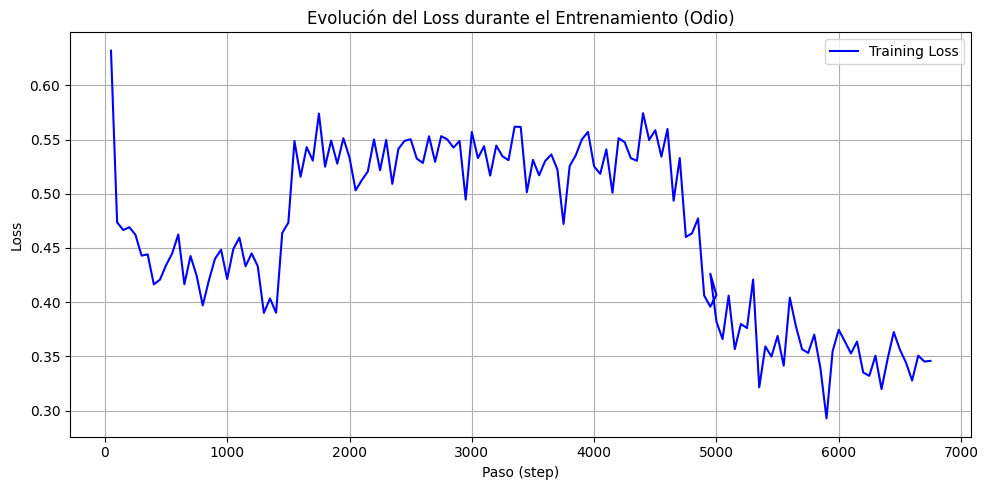

<ipython-input-1-d8011a7ca6f4>:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metrics_to_plot = df_metrics[df_metrics['metric_name'].str.contains('eval_(accuracy|f1_macro|precision_macro|recall_macro)')]


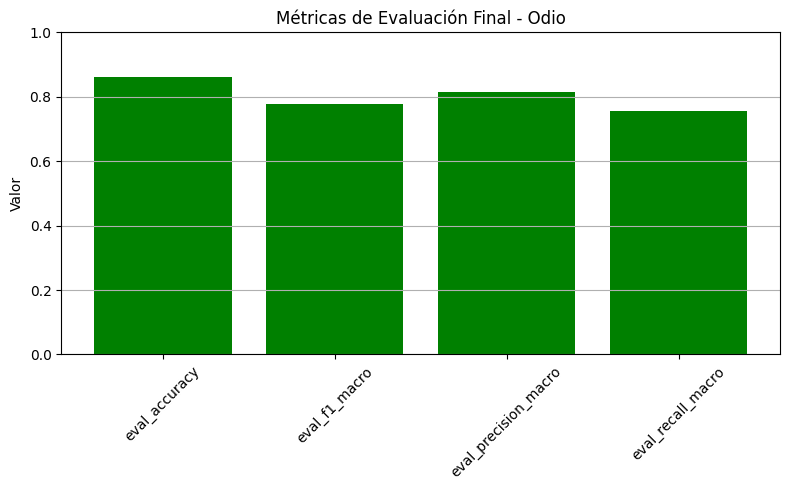

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_loss = pd.read_csv('/content/loss_log hs.csv')
df_metrics = pd.read_csv('/content/metrics_log hs.csv')

# Evolución del loss durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(df_loss['step'], df_loss['loss'], label='Training Loss', color='blue')
plt.xlabel('Paso (step)')
plt.ylabel('Loss')
plt.title('Evolución del Loss durante el Entrenamiento (Odio)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


metrics_to_plot = df_metrics[df_metrics['metric_name'].str.contains('eval_(accuracy|f1_macro|precision_macro|recall_macro)')]

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(metrics_to_plot['metric_name'], metrics_to_plot['value'], color='green')
plt.ylim(0, 1)
plt.title('Métricas de Evaluación Final - Odio')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


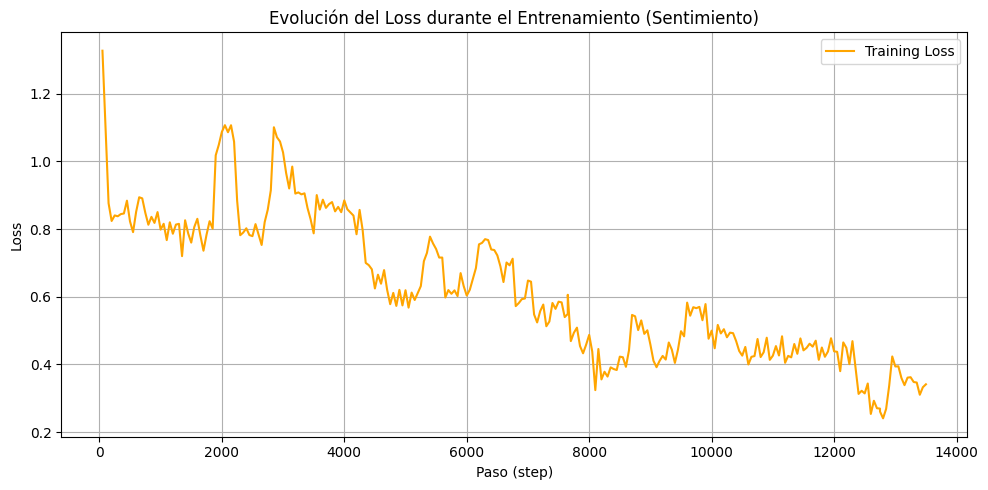

<ipython-input-2-bbead3fdcd8b>:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metrics_to_plot = df_metrics[df_metrics['metric_name'].str.contains('eval_(accuracy|f1_macro|precision_macro|recall_macro)')]


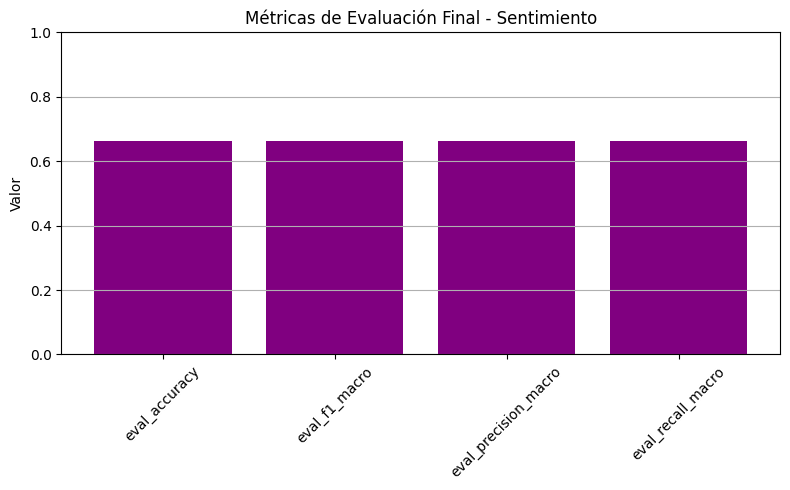

In [ ]:
df_loss = pd.read_csv('/content/loss_log sent.csv')
df_metrics = pd.read_csv('/content/metrics_log sent.csv')

# Evolución del loss durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(df_loss['step'], df_loss['loss'], label='Training Loss', color='orange')
plt.xlabel('Paso (step)')
plt.ylabel('Loss')
plt.title('Evolución del Loss durante el Entrenamiento (Sentimiento)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

metrics_to_plot = df_metrics[df_metrics['metric_name'].str.contains('eval_(accuracy|f1_macro|precision_macro|recall_macro)')]

plt.figure(figsize=(8, 5))
plt.bar(metrics_to_plot['metric_name'], metrics_to_plot['value'], color='purple')
plt.ylim(0, 1)
plt.title('Métricas de Evaluación Final - Sentimiento')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
